In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
# 1. Загрузка данных
train_raw = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test_raw = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

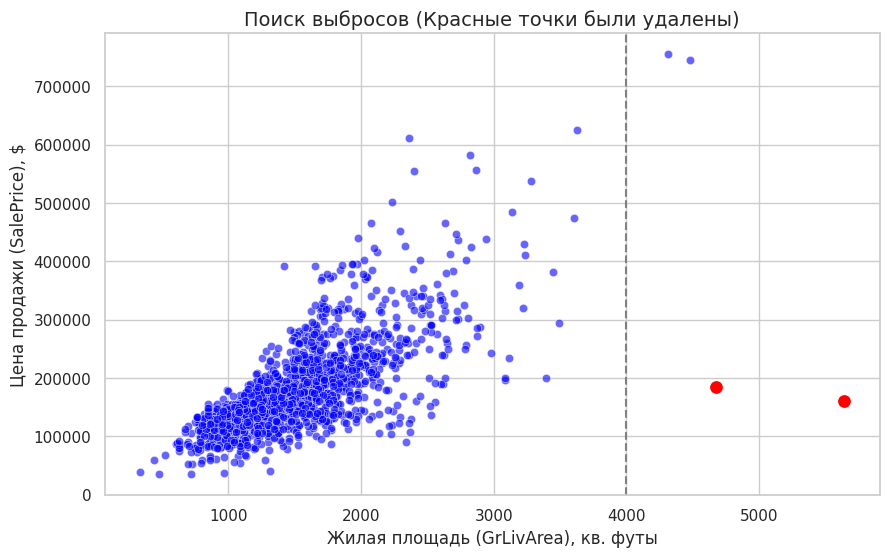

In [3]:
sns.set_theme(style="whitegrid")

# 1. Поиск и удаление выбросов

plt.figure(figsize=(10, 6))
# Рисуем все точки
sns.scatterplot(
    data=train_raw, x="GrLivArea", y="SalePrice", color="blue", alpha=0.6
)

# Подсветим красным цветом те выбросы, которые мы удалили
outliers = train_raw[
    (train_raw["GrLivArea"] > 4000) & (train_raw["SalePrice"] < 300000)
]
sns.scatterplot(data=outliers, x="GrLivArea", y="SalePrice", color="red", s=100)

plt.title("Поиск выбросов (Красные точки были удалены)", fontsize=14)
plt.xlabel("Жилая площадь (GrLivArea), кв. футы")
plt.ylabel("Цена продажи (SalePrice), $")
plt.axvline(x=4000, color="gray", linestyle="--")
plt.savefig("1_outliers.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:

# Удаление выбросов из обучающей выборки
train_raw = train_raw.drop(
    train_raw[(train_raw["GrLivArea"] > 4000) & (train_raw["SalePrice"] < 300000)].index
)

test_ids = test_raw["Id"]

In [5]:
# 2. Очистка и генерация доп данных
def data_cleaning(df_raw):
    df = df_raw.copy()
    colunms_to_drop = ["PoolQC", "MiscFeature", "Alley", "Fence", "Id"]
    df = df.drop(columns=[col for col in colunms_to_drop if col in df.columns])

    if "LotFrontage" in df.columns and "Neighborhood" in df.columns:
        df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
            lambda x: x.fillna(x.median())
        )

    #  сложение площадей
    area_columns = ["1stFlrSF", "2ndFlrSF", "TotalBsmtSF"]
    if all(col in df.columns for col in area_columns):
        df["TotalSF"] = (
            df["1stFlrSF"].fillna(0)
            + df["2ndFlrSF"].fillna(0)
            + df["TotalBsmtSF"].fillna(0)
        )

    # общий возраст дома и возраст после ремонта
    if "YearBuilt" in df.columns and "YrSold" in df.columns:
        df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
        df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

    return df


train_df = data_cleaning(train_raw)
test_df = data_cleaning(test_raw)

In [6]:
X = train_df.drop("SalePrice", axis=1)
y = np.log1p(train_df["SalePrice"])  # логарифмируем таргет сразу
test_df = test_df[X.columns]

# Разделение признаков
number_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

In [7]:
# 3. Пайплайн предобработки 
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "power",
                        PowerTransformer(method="yeo-johnson"),
                    ),  
                ]
            ),
            number_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
                ]
            ),
            categorical_features,
        ),
    ]
)


In [8]:
sns.set_theme(style="whitegrid")

import scipy.sparse as sp

# Проверяем тип X_transformed
print(f"Тип X_transformed: {type(X_transformed)}")

# Преобразуем нужную колонку в плотный массив
if sp.issparse(X_transformed):
    # Извлекаем колонку и преобразуем в плотный массив
    lot_area_dense = X_transformed[:, lot_area_idx].toarray().ravel()
else:
    lot_area_dense = X_transformed[:, lot_area_idx]

# Рисуем график
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# До исправления
sns.histplot(train_raw["LotArea"], kde=True, ax=axes[0], color="red")
axes[0].set_title("Распределение LotArea ДО (Сильный перекос)")
axes[0].set_xlabel("Площадь участка")

# После исправления
sns.histplot(lot_area_dense, kde=True, ax=axes[1], color="green")
axes[1].set_title("Распределение LotArea ПОСЛЕ (Красивый колокол)")
axes[1].set_xlabel("Трансформированная площадь")

plt.suptitle("Как PowerTransformer выровнял данные ", fontsize=14)
plt.tight_layout()
plt.savefig("2_skewness_fixed.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'X_transformed' is not defined

In [ ]:
# Применяем трансформацию ко всей матрице
X_transformed = preprocessor.fit_transform(X)
X_test_transformed = preprocessor.transform(test_df)

# 4. Инициализация моделей
model_cb = CatBoostRegressor(
    iterations=1000, 
    learning_rate=0.03, 
    depth=6, verbose=0, 
    random_seed=42
)
model_xgb = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.03, 
    max_depth=5, 
    random_state=42,
    subsample=0.8
)
model_lgb = LGBMRegressor(
    n_estimators=1000, 
    learning_rate=0.03, 
    max_depth=5, 
    random_state=42, 
    subsample=0.8, 
    verbose=-1
)

# 5. Обучение на 5-фолдовой Кросс-Валидации (K-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_df))

In [ ]:

fold_rmse = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_transformed, y)):
    X_tr, y_tr = X_transformed[train_idx], y.iloc[train_idx]
    X_va, y_va = X_transformed[val_idx], y.iloc[val_idx]

    # Обучаем модели на текущем фолде
    model_cb.fit(X_tr, y_tr)
    model_xgb.fit(X_tr, y_tr)
    model_lgb.fit(X_tr, y_tr)

    # Усредняем их предсказания на валидации 
    val_pred = (
        model_cb.predict(X_va) * 0.4
        + model_xgb.predict(X_va) * 0.3
        + model_lgb.predict(X_va) * 0.3
    )
    oof_preds[val_idx] = val_pred

    # Считаем ошибку текущего фолда
    fold_score = np.sqrt(np.mean((y_va - val_pred) ** 2))
    fold_rmse.append(fold_score)
    print(f"Fold {fold+1} RMSE: {fold_score:.5f}")

    # Накапливаем предсказания для теста (деленные на количество фолдов)
    test_pred_fold = (
        model_cb.predict(X_test_transformed) * 0.4
        + model_xgb.predict(X_test_transformed) * 0.3
        + model_lgb.predict(X_test_transformed) * 0.3
    )
    test_preds += test_pred_fold / kf.n_splits

print(f"\nОбщий средний CV RMSE: {np.mean(fold_rmse):.5f}")


In [ ]:

# 3. Проверка точности (Реальность vs Предсказание)

plt.figure(figsize=(8, 8))

# Берем данные из кросс-валидации 
# Переводим обратно из логарифмов в реальные доллары через np.expm1
real_prices = np.expm1(y)
predicted_prices = np.expm1(oof_preds)

sns.scatterplot(x=real_prices, y=predicted_prices, alpha=0.5, color="purple")

#  линия идеала 
perfect_line = [real_prices.min(), real_prices.max()]
plt.plot(perfect_line, perfect_line, color="red", linestyle="--", linewidth=2)

plt.title(
    f"Насколько точно угадывает наш консилиум? (CV RMSE: 12.557)", fontsize=14
)
plt.xlabel("Реальная цена дома, $")
plt.ylabel("Предсказанная цена моделью, $")
plt.savefig("3_predictions_vs_reality.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# 6. Экспорт результатов
final_test_preds = np.expm1(test_preds)
submission = pd.DataFrame({"Id": test_ids, "SalePrice": final_test_preds})
submission.to_csv("submission.csv", index=False)
print("Финальный сабмит успешно сгенерирован!")